## Comparison of GloGEM, PyGEM, and OGGM RGI 11 Runoff Outputs 

This notebook imports and processes GloGEM, PyGEM, and OGGM RGI 11 outputs. Summing glacial runoff by basin, we produce a plot that compares the three models' projected runoff values for each basin by SSP. 

Last Updated: 6 June 2023 | FFW

### Aggregation of GloGEM runoff:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from datetime import date
import collections
import datetime
import os
import xarray as xr

## Generic the filepath to the main data folder
fpath0 = '/Users/finnwimberly/Library/CloudStorage/GoogleDrive-fwimberly@middlebury.edu/My Drive/Lizz Research Stuff/Runoff-intercomparison/GloGEM-output/RGI11-CentralEurope/files/'  

#All of the climate models used
modelnames = ['BCC-CSM2-MR','CAMS-CSM1-0','CESM2','CESM2-WACCM','EC-Earth3','EC-Earth3-Veg','FGOALS-f3-L','GFDL-ESM4',
              'INM-CM4-8','INM-CM5-0','MPI-ESM1-2-HR','MRI-ESM2-0', 'NorESM2-MM']

SSPpaths = ['ssp126','ssp245','ssp370','ssp585']   #Specifiying the SSP
#SSPs = ['ssp119','ssp126','ssp245','ssp370','ssp585'] #Use a different path as we have all 5 ssps for volume

In [2]:
all_discharges = [[] for _ in SSPpaths]

for s, SSPpath in enumerate(SSPpaths):
    model_discharges = []
    for modelname in modelnames:
        temp_df = pd.read_csv(fpath0 + modelname + '/' + SSPpaths[s]  + '/' + 'centraleurope_Discharge_r1.dat', sep='\s+', header=None, skiprows=1, index_col=0)
        model_discharges.append(temp_df)
    all_discharges[s] = model_discharges

In [3]:
all_areas = [[] for _ in SSPpaths]

for s, SSPpath in enumerate(SSPpaths):
    model_areas = []
    for modelname in modelnames:
        temp_df = pd.read_csv(fpath0 + modelname  + '/' + SSPpaths[s]  + '/' + 'centraleurope_Area_r1.dat', sep='\s+', index_col="ID")
        model_areas.append(temp_df)
    all_areas[s] = model_areas

In [4]:
# Create new index using pandas date_range function
start_date = datetime.date(1980, 1, 1)
end_date = datetime.date(2100, 12, 1)
new_indices = pd.date_range(start_date, end_date, freq='MS').strftime('%Y-%m').tolist()

# Apply new index and datetime conversion
for s, SSPpath_discharges in enumerate(all_discharges):
    for m, discharge_df in enumerate(SSPpath_discharges):
        all_discharges[s][m].columns = new_indices
        all_discharges[s][m].columns = pd.to_datetime(new_indices)

In [5]:
#expanding area dataset to match year-month dimension
for s in range(len(SSPpaths)):
    for i in range(len(all_areas[s])):
        all_areas[s][i] = all_areas[s][i][all_areas[s][i].columns.repeat(12)]
        
for s, areas in enumerate(all_areas):
    for i, area in enumerate(areas):
        all_areas[s][i].columns = new_indices
        all_areas[s][i].columns = pd.to_datetime(new_indices)

In [6]:
# We will use our initial area to compute runoff so we fill entire dfs with element 0
# We only use one SSP because the initial areas are all the same -- we save time without looping through all
# We also convert km^2 to m^2

initial_areas = [pd.DataFrame(df.iloc[:, 0].values.repeat(df.shape[1]).reshape(df.shape), index=df.index, columns=df.columns).mul(1e6) for df in all_areas[0]]

In [7]:
runoff = {s: {m: None for m in modelnames} for s in SSPpaths} # create nested dictionary indexed by model name and ssp
n=0
for s in SSPpaths:
    i=0
    for m in modelnames:
        runoff[s][m] = pd.concat([initial_areas[i] * all_discharges[n][i]], axis=1)
        i+=1
    n+=1

In [8]:
import itertools
annualrunoff = {s: {m: None for m in modelnames} for s in SSPpaths}
for s, m in itertools.product(SSPpaths, modelnames):
    annualrunoff[s][m] = runoff[s][m].transpose().resample('A').sum() * 1e-9 #m^3 to km^3

In [9]:
import json
def select_glaciers_json(basin='all'):
    '''
    Select glaciers within a basin by MRBID from a json-file,
    which is stored in the data directory.

    Args:
    -----
    basin: str
        String of MRBID or 'all'.

    Returns:
    --------
    If basin is 'all' a list of all relevant glaciers is returned, for
    initiating glacier simulations. If basin is a MRBID the list of glaciers
    within that basin is returned.
    
    Copy of a function written by Erik Holmgren (2022) in holmgren_gha.utils
    '''

    # fpath = './data/rgi_ids_per_basin.json'
    fpath = '/Users/finnwimberly/Library/CloudStorage/GoogleDrive-fwimberly@middlebury.edu/My Drive/Lizz Research Stuff/rgi_ids_per_basin.json'  
    with open(fpath) as f:
        basin_dict = json.load(f)

    if basin.lower() != 'all':
        glacier_list = basin_dict[basin]
    else:
        glacier_list = list(itertools.chain.from_iterable(basin_dict.values()))

    return glacier_list

In [10]:
def sum_basin(basin_RGI_list, runoff_data):
    # Create new list to match our RGI formatting
    new_basin_list = [int(str(x)[-4:]) for x in basin_RGI_list]
    runoff_data = runoff_data.transpose()
    
    #TODO: create list of glaciers within a basin that are not included in GloGEM output
    # Filter new_basin_list to keep only the indexes present in the DataFrame
    new_basin_list = [x for x in new_basin_list if x in runoff_data.index]
    
    # Extract glaciers contained in the list from original df and create a new df
    new_df = runoff_data.loc[new_basin_list].copy()
    
    # Sum the values of the glaciers within the basin
    summed_basin_runoff = new_df.sum()
    #print(summed_basin_runoff)
    
    return summed_basin_runoff

In [11]:
#Generating the aggregated basin data
alpine_basins = {'RHINE':'6242', 'RHONE':'6243','PO':'6241', 'DANUBE':'6202'} ## GRDC Major River Basin identifiers for the 3 alpine basins we can study
modelnames_glo = ['BCC-CSM2-MR','CAMS-CSM1-0','CESM2','CESM2-WACCM','EC-Earth3','EC-Earth3-Veg','FGOALS-f3-L','GFDL-ESM4',
              'INM-CM4-8','INM-CM5-0','MPI-ESM1-2-HR','MRI-ESM2-0', 'NorESM2-MM']

scenarios = ['ssp126','ssp245','ssp370','ssp585']

basins = ['RHINE', 'RHONE', 'PO', 'DANUBE']

basin_sums_glo = {}
basin_sums_monthly_glo = {}
for s, SSP in enumerate(scenarios):
    basin_sums_glo[SSP] = {}
    basin_sums_monthly_glo[SSP] = {}
    for b, basin in enumerate(basins):
        basin_sums_glo[SSP][basin] = {}
        basin_sums_monthly_glo[SSP][basin] = {}
        for m, model in enumerate(modelnames_glo):
            basin_sums_glo[SSP][basin][model] = sum_basin(select_glaciers_json(alpine_basins[basin]), annualrunoff[SSP][model]) 
            basin_sums_monthly_glo[SSP][basin][model] = sum_basin(select_glaciers_json(alpine_basins[basin]), runoff[SSP][model].transpose()*1e-9) 

In [12]:
#To calculate multi GCM means and Quartiles we convert to df then calculate across first axis (GCMs)
GCM_mean_glo = {}
GCM_q1_glo = {}
GCM_q3_glo = {}
for s, SSP in enumerate(SSPpaths):
    GCM_mean_glo[SSP] = {}
    GCM_q1_glo[SSP] = {}
    GCM_q3_glo[SSP] = {}
    for b, basin in enumerate(basins):
        GCM_mean_glo[SSP][basin] = pd.DataFrame(basin_sums_glo[SSP][basin]).mean(axis=1)
        GCM_q1_glo[SSP][basin] = pd.DataFrame(basin_sums_glo[SSP][basin]).quantile(q=0.25, axis=1)
        GCM_q3_glo[SSP][basin] = pd.DataFrame(basin_sums_glo[SSP][basin]).quantile(q=0.75, axis=1)

### Aggregation of PyGEM runoff:

In [13]:
import xarray as xr

#All of the climate models used
modelnames_py = ['BCC-CSM2-MR','CESM2','CESM2-WACCM','EC-Earth3','EC-Earth3-Veg','FGOALS-f3-L','GFDL-ESM4',
              'INM-CM4-8','INM-CM5-0','MPI-ESM1-2-HR','MRI-ESM2-0', 'NorESM2-MM']

SSPs = ['ssp126','ssp245','ssp370','ssp585'] #List of all SSPs in PyGEM
which_ssp = SSPs[0]

alpine_basins = {'RHINE': '6242',
                 'RHONE': '6243',
                 'PO': '6241',
                 'DANUBE':'6202'} ## GRDC Major River Basin identifiers for the 4 alpine basins we can study

test_basin = alpine_basins['RHONE'] 

#Generic filepath to navigate to Drive folder 
fpathPy = '/Users/finnwimberly/Library/CloudStorage/GoogleDrive-fwimberly@middlebury.edu/My Drive/Lizz Research Stuff/11'

In [14]:
basin_gls = {}
for basin, code in alpine_basins.items():
    basin_gls[basin] = select_glaciers_json(code)

In [15]:
#Importing all runoff data, taking annual sum, and converting m^3 to km^3
import glob   #use glob to group files by filename similarities (in this case, SSP)

rf_ds = {}
annual_rf_ds = {}
for s, SSP in enumerate(SSPs):
    fpath1 = '/R11_runoff_monthly_c2_ba1_1set_2000_2100-{}'.format(SSP)
    file_pattern = f'{fpathPy + fpath1}*.nc'
    file_list = glob.glob(file_pattern)
    
    datasets = []  # Create an empty list for each SSP
    if file_list:
        for file in file_list: 
            with xr.open_dataset(file) as ds:
                ds = ds.glac_runoff_monthly.load()
                datasets.append(ds)
    
        combined_ds = xr.concat(datasets, dim='glacier')  # Concatenate the datasets
        rf_ds[SSP] = combined_ds
        annual_rf_ds[SSP] = rf_ds[SSP].resample(time='A').sum() * 1e-9

In [16]:
# Sorting into basins
basin_datasets = {}
basin_ds_monthly = {}
for basin, glacier_list in basin_gls.items():
    ## loop over them all, drop the irrelevant IDs, and concatenate the result
    basin_datasets[basin] = {}
    basin_ds_monthly[basin] = {}
    for s, SSP in enumerate(SSPs):
        ds_list = []
        ds_list_monthly = []
        try:
            ds_filtered = annual_rf_ds[SSP].where(annual_rf_ds[SSP].RGIId.isin(glacier_list), drop=True)
            ds_filtered_monthly = rf_ds[SSP].where(rf_ds[SSP].RGIId.isin(glacier_list), drop=True)
            #print(ds_filtered)
            ds_list.append(ds_filtered)
            ds_list_monthly.append(ds_filtered_monthly)
        except ValueError: ## happens if there are no glaciers from this batch in the selected region
            continue
        basin_datasets[basin][SSP] = xr.concat(ds_list, dim='glacier')
        basin_ds_monthly[basin][SSP] = xr.concat(ds_list_monthly, dim='glacier') 

In [17]:
#Flipping indexing (to match other models) and summing basins
basin_sums_py = {}
basin_sums_monthly_py = {}
for s, SSP in enumerate(SSPs):        
    basin_sums_py[SSP] = {}
    basin_sums_monthly_py[SSP] = {}
    for basin, glacier_list in basin_gls.items():
        basin_sums_py[SSP][basin] = basin_datasets[basin][SSP].sum(dim='glacier')
        basin_sums_monthly_py[SSP][basin] = basin_ds_monthly[basin][SSP].sum(dim='glacier')*1e-9

In [18]:
#Compute multi GCM means and quartiles
GCM_mean_py = {}
GCM_q1_py = {}
GCM_q3_py = {}
for s, SSP in enumerate(SSPs):
    which_ssp = SSPs[s]
    GCM_mean_py[which_ssp] = {}
    GCM_q1_py[which_ssp] = {}
    GCM_q3_py[which_ssp] = {}
    for basin in basins:
        GCM_mean_py[which_ssp][basin] = basin_sums_py[which_ssp][basin].mean(dim = 'model')
        GCM_q1_py[which_ssp][basin] = basin_sums_py[which_ssp][basin].quantile(q = 0.25, dim = 'model')
        GCM_q3_py[which_ssp][basin] = basin_sums_py[which_ssp][basin].quantile(q = 0.75, dim = 'model')

Text(-1.28, 4.72, 'Rhine River Basin                 Rhone River Basin                    Po River Basin                   Danube River Basin')

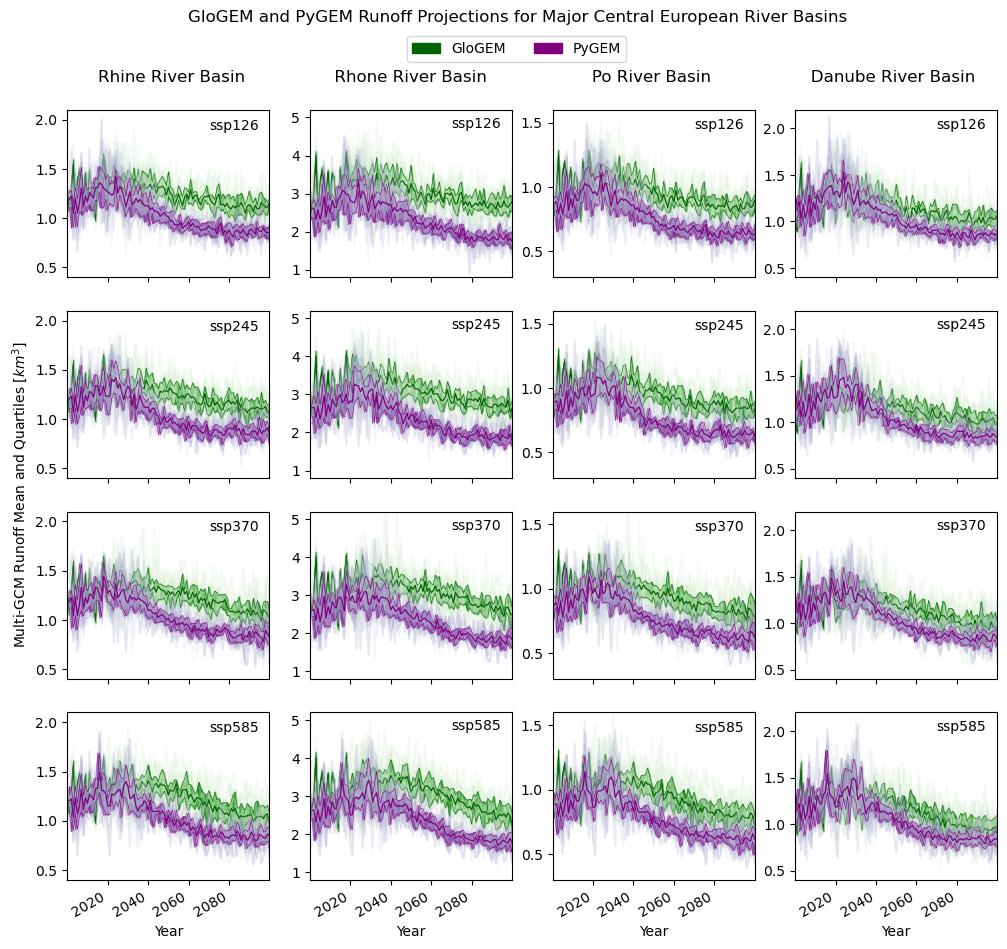

In [19]:
from cycler import cycler
import matplotlib.patches as mpatches

scenarios = ['ssp126','ssp245','ssp370','ssp585']
basins = ['RHINE', 'RHONE', 'PO','DANUBE']

yrs_glo = np.arange(1980,2101)
yrs_glo_dt = pd.to_datetime([str(y)for y in yrs_glo])

colors_glo =  plt.colormaps['Greens']
line_colors_glo = colors_glo(np.linspace(0.2, 0.6, num = 12))
glo_cycler = cycler(color = line_colors_glo)

colors_py =  plt.colormaps['Purples']
line_colors_py = colors_py(np.linspace(0.2, 0.6,num = 12))
py_cycler = cycler(color = line_colors_py)

ssp_label_pos = [1.9, 4.73, 1.45, 2.0]

#Plotting all data
fig, axs = plt.subplots(len(scenarios), 4, figsize=(12, 10), sharex=True)
for s, SSP in enumerate(scenarios):
    which_ssp = SSPs[s]
    for b, basin in enumerate(basins):
        for m in modelnames_glo:
            axs[s, b].plot(yrs_glo_dt, basin_sums_glo[which_ssp][basin][m], color=axs[s, b].set_prop_cycle(glo_cycler), alpha = 0.25)
        axs[s,b].plot(yrs_glo_dt, GCM_mean_glo[which_ssp][basin], color = 'darkgreen', linewidth = 0.9)
        axs[s,b].plot(yrs_glo_dt, GCM_q1_glo[which_ssp][basin], color = 'darkgreen', linewidth = 0.4)
        axs[s,b].plot(yrs_glo_dt, GCM_q3_glo[which_ssp][basin], color = 'darkgreen', linewidth = 0.4)
        axs[s,b].fill_between(yrs_glo_dt, GCM_q1_glo[which_ssp][basin], GCM_q3_glo[which_ssp][basin], color = 'green')
        axs[s, b].set(xlim=(pd.to_datetime('2000-01-01'), pd.to_datetime('2100-01-01')))

        basin_sums_py[which_ssp][basin].plot(hue='model', ax=axs[s, b], color=axs[s, b].set_prop_cycle(py_cycler), alpha = 0.25, add_legend=False)
        GCM_mean_py[which_ssp][basin].plot(hue='model', ax=axs[s, b], color = 'purple', linewidth = 0.9, add_legend=False)
        GCM_q1_py[which_ssp][basin].plot(hue='model', ax=axs[s, b], color = 'purple', linewidth = 0.4, add_legend=False)
        GCM_q3_py[which_ssp][basin].plot(hue='model', ax=axs[s, b], color = 'purple', linewidth = 0.4, add_legend=False)
        axs[s,b].fill_between(yrs_glo_dt[20::], GCM_q1_py[which_ssp][basin], GCM_q3_py[which_ssp][basin], color = 'Purple')
        axs[s,b].set(title = '')

        #Setting x and y labels and making y limits uniform within basins
        if s == 3:
            for sub_b in range(4):  # Use a different variable name for the inner loop
                axs[s, sub_b].set_xlabel('Year')
                axs[s, sub_b].set_xticks([pd.to_datetime('2020'),pd.to_datetime('2040'), pd.to_datetime('2060'), pd.to_datetime('2080')], [2020, 2040, 2060, 2080])
        else:
            axs[s, b].set_xlabel(None)
            
        if b == 0:
            for sub_s in range(4):  # Use a different variable name for the inner loop
                axs[sub_s, b].set(ylim = (0.4,2.1))
                if sub_s == 2:
                    axs[sub_s, b].set_ylabel(r'Multi-GCM Runoff Mean and Quartiles $[km^3]$', y=1.1)
            else:
                axs[s, b].set_ylabel(None)
            
        if b == 1:
            for sub_s in range(4):  # Use a different variable name for the inner loop
                axs[sub_s, b].set(ylim = (0.8,5.2))
                axs[s, b].set_ylabel(None)
        if b == 2:
            for sub_s in range(4):  # Use a different variable name for the inner loop
                axs[sub_s, b].set_yticks([0.5, 1.0, 1.5]) 
                axs[sub_s, b].set(ylim = (0.3,1.6))
                axs[s, b].set_ylabel(None)
        if b == 3:
            for sub_s in range(4):  # Use a different variable name for the inner loop
                axs[sub_s, b].set(ylim = (0.4,2.2))
                axs[s, b].set_ylabel(None)

        axs[s, b].text(pd.to_datetime('2070-01-01'), ssp_label_pos[b], SSP)

green_patch = mpatches.Patch(color='darkgreen', label='GloGEM')
purple_patch = mpatches.Patch(color='purple', label='PyGEM')       
axs[0,0].legend(handles=[green_patch, purple_patch], bbox_to_anchor=(2.8, 1.48), ncol=2)

#plt.subplots_adjust(hspace = 0.5)
plt.suptitle('GloGEM and PyGEM Runoff Projections for Major Central European River Basins')
plt.title('Rhine River Basin                 Rhone River Basin                    Po River Basin                   Danube River Basin', x=-1.28, y=4.72)

### Introducing OGGM Runoff

In [20]:
#All of the climate models used
modelnames_OG = ['BCC-CSM2-MR', 'CAMS-CSM1-0', 'CESM2', 'CESM2-WACCM', 'CMCC-CM2-SR5','EC-Earth3', 
                'EC-Earth3-Veg', 'FGOALS-f3-L', 'GFDL-ESM4', 'INM-CM4-8','INM-CM5-0', 
                 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorESM2-MM', 'TaiESM1']

alpine_basins = {'RHINE': '6242','RHONE': '6243','PO': '6241','DANUBE':'6202'}

basins = ['RHINE', 'RHONE', 'PO', 'DANUBE']

SSPs = ['ssp126','ssp245','ssp370','ssp585']

# CMCC-CM2-SR5 & TaiESM1 only hold values for ssp585––this is model list without those GCMS
modelnames_OG_trimmed = ['BCC-CSM2-MR', 'CAMS-CSM1-0', 'CESM2', 'CESM2-WACCM', 'EC-Earth3', 
                         'EC-Earth3-Veg', 'FGOALS-f3-L', 'GFDL-ESM4', 'INM-CM4-8',
                           'INM-CM5-0', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorESM2-MM']

#Generic filepath to navigate to Drive folder 
fpathOG1 = '/Users/finnwimberly/Library/CloudStorage/GoogleDrive-fwimberly@middlebury.edu/My Drive/'
fpathOG2 = 'Lizz Research Stuff/Runoff-intercomparison/OGGM/lschuster/runs_2023.3/output/basins/'

In [21]:
#Importing all runoff data, OGGM is grouped by basin
rf_ds = {}
rf_ds_monthly = {}
for basin, ID in alpine_basins.items():
    fpath_basin = 'gcm_from_2000_bc_2000_2019/{}/'.format(ID)
    #print(f'{fpathOG + fpath_basin} (1)/*.nc')
    with xr.open_mfdataset(f'{fpathOG1 + fpathOG2 + fpath_basin}/*.nc') as ds1:
        ds1 = ds1.runoff.load()
    rf_ds[basin] = ds1
    with xr.open_mfdataset(f'{fpathOG1 + fpathOG2 + fpath_basin}*.nc') as ds2:
        ds_monthly = ds2.runoff_monthly.load()
    rf_ds_monthly[basin] = ds_monthly

In [22]:
#Summing individual glacier runoff into basin totals and converting kg to km^3
basin_rf_OG = {}
basin_rf_monthly_OG = {}
for basin, ID in alpine_basins.items():
    basin_rf_OG[basin] = rf_ds[basin].sum(dim = 'rgi_id') * 1e-12
    basin_rf_monthly_OG[basin] = rf_ds_monthly[basin].sum(dim = 'rgi_id') * 1e-12

In [23]:
#creating dict of GloPy format
basin_sums_OG = {}
basin_sums_monthly_OG = {}
for s, SSP in enumerate(SSPs):
    basin_sums_OG[SSP] = {}
    basin_sums_monthly_OG[SSP] = {}
    for b, basin in enumerate(basins):
        basin_sums_OG[SSP][basin] = basin_rf_OG[basin].sel(scenario = SSP)
        basin_sums_monthly_OG[SSP][basin] = basin_rf_monthly_OG[basin].sel(scenario = SSP)

In [24]:
#Plotting it looks like some GCMs contain all-zero values, like:
basin_sums_OG['ssp126']['DANUBE'][14]

<xarray.DataArray 'runoff' (time: 101)>
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)
Coordinates:
  * time             (time) float64 2e+03 2.001e+03 ... 2.099e+03 2.1e+03
    scenario         <U6 'ssp126'
    gcm              <U7 'TaiESM1'
    hydro_year       (time) int64 2000 2001 2002 2003 ... 2097 2098 2099 2100
    hydro_month      (time) int64 4 4 4 4 4 4 4 4 4 4 4 ... 4 4 4 4 4 4 4 4 4 4
    calendar_year    (time) int64 2000 2001 2002 2003 ... 2097 2098 2099 2100
    calendar_month   (time) int64 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
    bias_correction  <U12 'bc_2000_2019'

In [25]:
#Removing these GCMs for ALL SSPs--doing even 585 as these two are not included...
#... in Glo or Py so not only makeds OOGM easier but maintains GCM consistency in analysis
trimmed_basin_sums_OG = {}
trimmed_basin_sums_monthly_OG = {}
for s, SSP in enumerate(SSPs):
    trimmed_basin_sums_OG[SSP] = {}
    trimmed_basin_sums_monthly_OG[SSP] = {}
    for b, basin in enumerate(basins):
        trimmed_basin_sums_OG[SSP][basin] = xr.concat([basin_sums_OG[SSP][basin][0:4], basin_sums_OG[SSP][basin][5:-1]], dim='gcm')
        trimmed_basin_sums_monthly_OG[SSP][basin] = xr.concat([basin_sums_monthly_OG[SSP][basin][0:4], basin_sums_monthly_OG[SSP][basin][5:-1]], dim='gcm')

In [26]:
#Compute multi GCM means and quartiles for OGGM
GCM_mean_OG = {}
GCM_q1_OG = {}
GCM_q3_OG = {}
for s, SSP in enumerate(SSPs):
    which_ssp = SSPs[s]
    GCM_mean_OG[which_ssp] = {}
    GCM_q1_OG[which_ssp] = {}
    GCM_q3_OG[which_ssp] = {}
    for basin in basins:
        GCM_mean_OG[which_ssp][basin] = trimmed_basin_sums_OG[which_ssp][basin].mean(dim = 'gcm')
        GCM_q1_OG[which_ssp][basin] = trimmed_basin_sums_OG[which_ssp][basin].quantile(q = 0.25, dim = 'gcm')
        GCM_q3_OG[which_ssp][basin] = trimmed_basin_sums_OG[which_ssp][basin].quantile(q = 0.75, dim = 'gcm')

In [27]:
#Plot setup
from cycler import cycler
import matplotlib.patches as mpatches

scenarios = ['ssp126','ssp245','ssp370','ssp585']
basins = ['RHINE', 'RHONE', 'PO','DANUBE']
basinstext = ['Rhine', 'Rhone', 'Po','Danube']

yrs_glo = np.arange(1980,2101)
yrs_glo_dt = pd.to_datetime([str(y)for y in yrs_glo])

colors_glo =  plt.colormaps['Greens']
line_colors_glo = colors_glo(np.linspace(0.2, 0.6, num = 12))
glo_cycler = cycler(color = line_colors_glo)

colors_py =  plt.colormaps['Purples']
line_colors_py = colors_py(np.linspace(0.2, 0.6,num = 12))
py_cycler = cycler(color = line_colors_py)

colors_OG =  plt.colormaps['Blues']
line_colors_OG = colors_OG(np.linspace(0.2, 0.6,num = 12))
OG_cycler = cycler(color = line_colors_OG)

In [28]:
#Calculating variance for additional plot
variance_glo = {}
variance_py = {}
variance_OG = {}
for s, SSP in enumerate(SSPs):
    variance_glo[SSP] = {}
    variance_py[SSP] = {}
    variance_OG[SSP] = {}
    for b, basin in enumerate(basins):
        variance_glo[SSP][basin] = pd.DataFrame(basin_sums_glo[SSP][basin]).var(axis=1)
        variance_py[SSP][basin] = basin_sums_py[SSP][basin].var(dim = 'model')
        variance_OG[SSP][basin] =  trimmed_basin_sums_OG[SSP][basin].var(dim = 'gcm')

Text(-1.3, 4.66, 'SSP 126                                 SSP 245                                SSP 370                                 SSP 585')

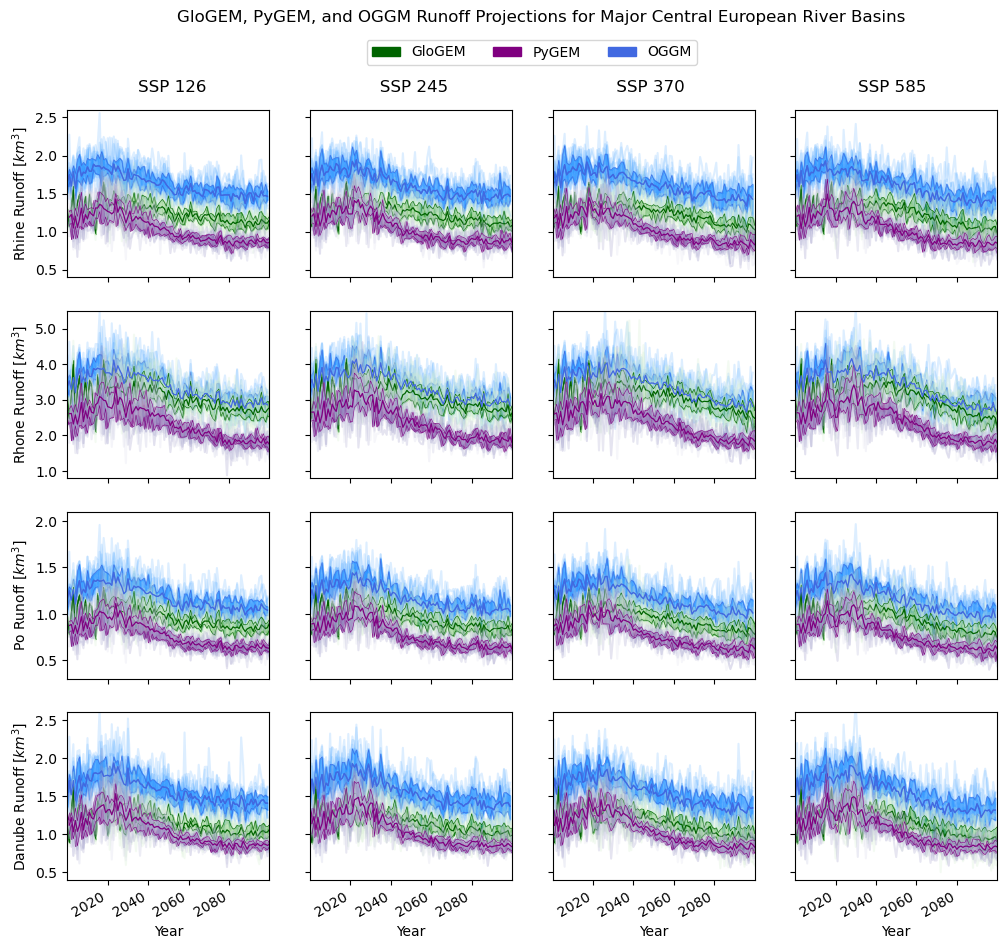

In [30]:
#Same plot as above with OGGM data added
#Also flipping axes so that l to r reads as one basin with increasing scenario severity 
#Plotting all data
fig, axs = plt.subplots(len(scenarios), 4, figsize=(12, 10), sharex=True)
for s, SSP in enumerate(scenarios):
    which_ssp = SSPs[s]
    for b, basin in enumerate(basins):

        #OG won't plot with built-in ds.plot()
        #Trim last value as it goes to zero
        for m, model in enumerate(modelnames_OG_trimmed):
            axs[b,s].plot(yrs_glo_dt[20:-1], trimmed_basin_sums_OG[which_ssp][basin][:,0:-1].sel(gcm = modelnames_OG_trimmed[m]), color = 'dodgerblue', alpha = 0.15)
        axs[b,s].plot(yrs_glo_dt[20:-1], GCM_mean_OG[which_ssp][basin][0:-1], color = 'royalblue', linewidth = 0.9)
        axs[b,s].plot(yrs_glo_dt[20:-1], GCM_q1_OG[which_ssp][basin][0:-1], color = 'royalblue', linewidth = 0.4)
        axs[b,s].plot(yrs_glo_dt[20:-1], GCM_q3_OG[which_ssp][basin][0:-1], color = 'royalblue', linewidth = 0.4)
        axs[b,s].fill_between(yrs_glo_dt[20:-1], GCM_q1_OG[which_ssp][basin][0:-1], GCM_q3_OG[which_ssp][basin][0:-1], color = 'dodgerblue', alpha = 0.5)

        #Trim first value as it is incomplete hydrological year
        for m in modelnames_glo:
            axs[b, s].plot(yrs_glo_dt, basin_sums_glo[which_ssp][basin][m], color=axs[b, s].set_prop_cycle(glo_cycler), alpha = 0.25)
        axs[b,s].plot(yrs_glo_dt, GCM_mean_glo[which_ssp][basin], color = 'darkgreen', linewidth = 0.9)
        axs[b,s].plot(yrs_glo_dt, GCM_q1_glo[which_ssp][basin], color = 'darkgreen', linewidth = 0.4)
        axs[b,s].plot(yrs_glo_dt, GCM_q3_glo[which_ssp][basin], color = 'darkgreen', linewidth = 0.4)
        axs[b,s].fill_between(yrs_glo_dt, GCM_q1_glo[which_ssp][basin], GCM_q3_glo[which_ssp][basin], color = 'green')
        axs[b, s].set(xlim=(pd.to_datetime('2000-01-01'), pd.to_datetime('2100-01-01')))

        basin_sums_py[which_ssp][basin].plot(hue='model', ax=axs[b, s], color=axs[b, s].set_prop_cycle(py_cycler), alpha = 0.25, add_legend=False)
        GCM_mean_py[which_ssp][basin].plot(hue='model', ax=axs[b, s], color = 'purple', linewidth = 0.9, add_legend=False)
        GCM_q1_py[which_ssp][basin].plot(hue='model', ax=axs[b, s], color = 'purple', linewidth = 0.4, add_legend=False)
        GCM_q3_py[which_ssp][basin].plot(hue='model', ax=axs[b, s], color = 'purple', linewidth = 0.4, add_legend=False)
        axs[b,s].fill_between(yrs_glo_dt[20::], GCM_q1_py[which_ssp][basin], GCM_q3_py[which_ssp][basin], color = 'Purple')
        axs[b,s].set(title = '')

        #Make mean more clear for RHONE, which overlaps significantly w Glo
        axs[b,s].plot(yrs_glo_dt[20:-1], GCM_mean_OG[which_ssp][basin][0:-1], color = 'royalblue', linewidth = 0.9)

        #Setting x and y labels and making y limits uniform within basins
        if b == 3:
            for sub_s in range(4):  # Use a different variable name for the inner loop
                axs[b, sub_s].set_xlabel('Year')
                axs[b, sub_s].set_xticks([pd.to_datetime('2020'),pd.to_datetime('2040'), pd.to_datetime('2060'), pd.to_datetime('2080')], [2020, 2040, 2060, 2080])
        else:
            axs[b, s].set_xlabel(None) 
        if b == 0:
            for sub_s in range(4):  # Use a different variable name for the inner loop
                axs[b, sub_s].set_yticks([0.5, 1.0, 1.5, 2.0, 2.5]) 
                axs[b, sub_s].set(ylim = (0.4,2.6))
        if b == 1:
            for sub_s in range(4): 
                y_ticks = [1.0, 2.0, 3.0, 4.0, 5.0]
                y_tick_labels = [f'{tick:.1f}' for tick in y_ticks] 
                axs[b, sub_s].set_yticks(y_ticks)
                axs[b, sub_s].set(ylim = (0.8,5.5))
                if sub_s==0:
                    axs[b, sub_s].set_yticklabels(y_tick_labels)
                
        if b == 2:                                                                   #Setting y-limits for each basin
            for sub_s in range(4):  
                axs[b, sub_s].set_yticks([0.5, 1.0, 1.5, 2.0]) 
                axs[b, sub_s].set(ylim = (0.3,2.1))
        if b == 3:
            for sub_s in range(4):  
                axs[b, sub_s].set(ylim = (0.4,2.6))
        if s == 0:                                                                    #Setting basin labels
            for sub_b in range(4):
                axs[sub_b,s].set_ylabel(basinstext[sub_b]+ r' Runoff $[km^3]$')
        if s != 0:
            axs[b, s].set_ylabel(None)
            axs[b, s].set_yticklabels('')

green_patch = mpatches.Patch(color='darkgreen', label='GloGEM')
purple_patch = mpatches.Patch(color='purple', label='PyGEM') 
blue_patch = mpatches.Patch(color='royalblue', label='OGGM')
axs[0,0].legend(handles=[green_patch, purple_patch, blue_patch], bbox_to_anchor=(3.15, 1.46), ncol=3)

plt.suptitle('GloGEM, PyGEM, and OGGM Runoff Projections for Major Central European River Basins', x=0.52)
plt.title('SSP 126                                 SSP 245                                SSP 370                                 SSP 585', x=-1.3, y=4.66) 

Text(-1.3, 4.66, 'SSP 126                                 SSP 245                                SSP 370                                 SSP 585')

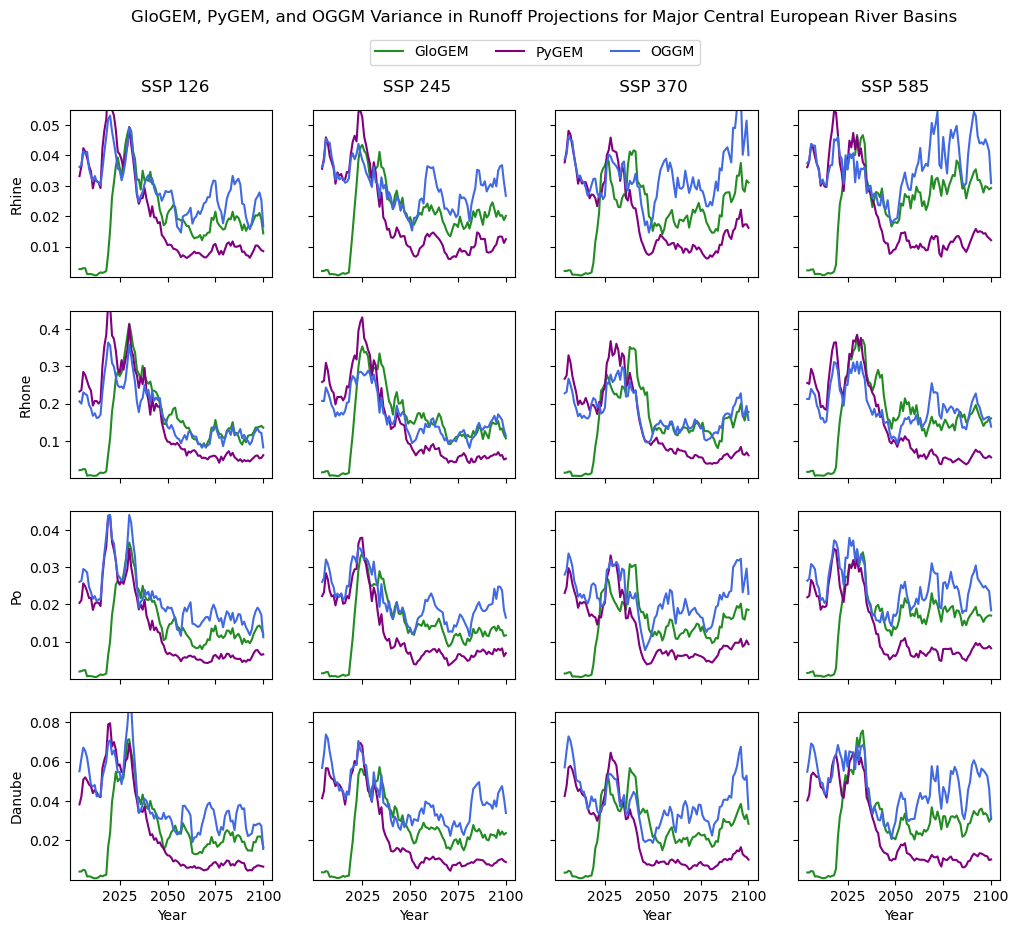

In [31]:
scenarios = ['ssp126','ssp245','ssp370','ssp585']
basins = ['RHINE', 'RHONE', 'PO','DANUBE']
basinstext = ['Rhine', 'Rhone', 'Po','Danube']

fig, axs = plt.subplots(len(scenarios), 4, figsize=(12, 10), sharex=True)
for s, SSP in enumerate(scenarios):
    for b, basin in enumerate(basins):
        axs[b,s].plot(yrs_glo_dt[20::], variance_glo[SSP][basin][20::].rolling(window=5).mean(), color = 'forestgreen', label = 'GloGEM')
        axs[b,s].plot(yrs_glo_dt[20::], variance_py[SSP][basin].rolling(time=5).mean(), color = 'purple', label = 'PyGEM')
        axs[b,s].plot(yrs_glo_dt[20::], variance_OG[SSP][basin].rolling(time=5).mean(), color = 'royalblue', label = 'OGGM')

        # axs[b,s].plot(yrs_glo_dt[20::], variance_glo[SSP][basin][20::], color = 'forestgreen', label = 'GloGEM')
        # axs[b,s].plot(yrs_glo_dt[20::], variance_py[SSP][basin], color = 'purple', label = 'PyGEM')
        # axs[b,s].plot(yrs_glo_dt[20::], variance_OG[SSP][basin], color = 'royalblue', label = 'OGGM')
        
        if b == 0:
            for sub_s in range(4):  # Use a different variable name for the inner loop
                axs[b, sub_s].set_yticks([0.01, 0.02, 0.03, 0.04, 0.05]) 
                axs[b, sub_s].set(ylim = (0,0.055))
        if b == 1:
            for sub_s in range(4): 
                axs[b, sub_s].set_yticks([0.10, 0.20, 0.30, 0.40])
                axs[b, sub_s].set(ylim = (0,0.45))
        if b == 2:                                                                   #Setting y-limits for each basin
            for sub_s in range(4):  
                axs[b, sub_s].set_yticks([0.01, 0.02, 0.03, 0.04])
                axs[b, sub_s].set(ylim = (0,0.045))
        if b == 3:
            for sub_s in range(4):  # Use a different variable name for the inner loop
                axs[b, sub_s].set_xlabel('Year')
                axs[b, sub_s].set_xticks([pd.to_datetime('2025'),pd.to_datetime('2050'), pd.to_datetime('2075'), pd.to_datetime('2100')], [2025, 2050, 2075, 2100])
                axs[b, sub_s].set_yticks([0.02, 0.04, 0.06, 0.08])
                axs[b, sub_s].set(ylim = (0,0.085))
        if s == 0:                                                                    #Setting basin labels
            for sub_b in range(4):
                axs[sub_b,s].set_ylabel(basinstext[sub_b])
        if s != 0:
            axs[b, s].set_ylabel(None)
            axs[b, s].set_yticklabels('')
        
axs[0,0].legend(bbox_to_anchor=(3.15, 1.46), ncol=3)
plt.suptitle('GloGEM, PyGEM, and OGGM Variance in Runoff Projections for Major Central European River Basins', x=0.52)
plt.title('SSP 126                                 SSP 245                                SSP 370                                 SSP 585', x=-1.3, y=4.66) 

### Inter-Annual Variance

In [32]:
#Calculating interannual variance
rolling_years = 15
yrs = np.arange(2000,2101)
yrs_dt = pd.to_datetime([str(y)for y in yrs])

annual_variance_glo = {}
annual_variance_py = {}
annual_variance_OG = {}
for s, SSP in enumerate(SSPs):
    annual_variance_glo[SSP] = {}
    annual_variance_py[SSP] = {}
    annual_variance_OG[SSP] = {}
    for b, basin in enumerate(basins):
        #annual_variance_glo[SSP][basin] = pd.DataFrame(basin_sums_glo[SSP][basin]).rolling(window= rolling_years, min_periods=10, center = True).var(axis=0)
        annual_variance_py[SSP][basin] = basin_sums_py[SSP][basin].rolling(time=rolling_years, min_periods=10, center = True).var()
        annual_variance_OG[SSP][basin] =  trimmed_basin_sums_OG[SSP][basin][0::,0:-1].rolling(time=rolling_years, min_periods=10, center = True).var()
        annual_variance_glo[SSP][basin] = {}
        for m in modelnames_glo:
            annual_variance_glo[SSP][basin][m]= pd.DataFrame(basin_sums_glo[which_ssp][basin][m]).rolling(window=rolling_years, min_periods=10, center = True).var()

In [33]:
mean_variance_glo = {}
for s, SSP in enumerate(SSPs):
    mean_variance_glo[SSP] = {}
    for b, basin in enumerate(basins):
        mean_variance_glo[SSP][basin] = GCM_mean_glo[SSP][basin].rolling(window=rolling_years, min_periods=10, center = True).var()

Text(-1.3, 4.66, 'SSP 126                                 SSP 245                                SSP 370                                 SSP 585')

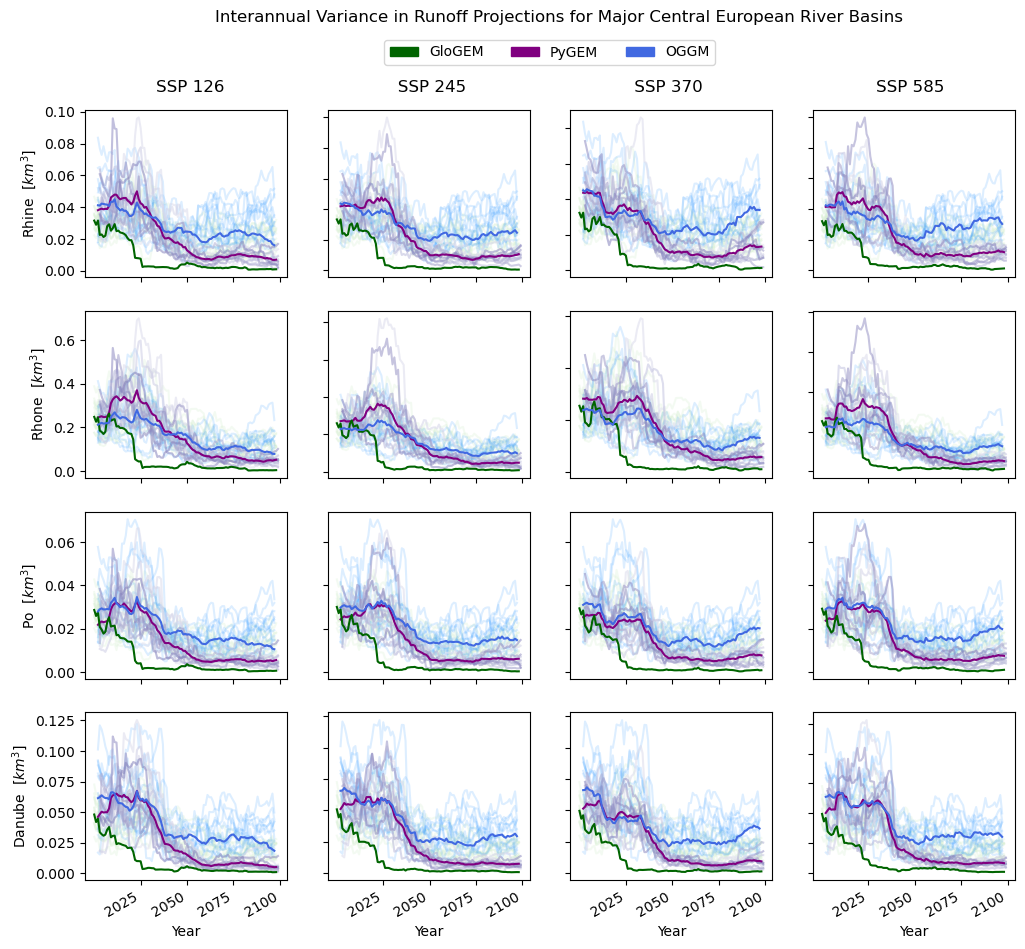

In [34]:
fig, axs = plt.subplots(len(basins), len(scenarios), figsize=(12, 10), sharex=True)
for s, SSP in enumerate(scenarios):
    for b, basin in enumerate(basins):
        
        for m in modelnames_glo:
            axs[b, s].plot(yrs_dt, annual_variance_glo[SSP][basin][m][20::], color=axs[b, s].set_prop_cycle(colorschemes[gmodel]), alpha = 0.25)
        
        for m, model in enumerate(modelnames_OG_trimmed):
            axs[b,s].plot(yrs_dt[0:-1], annual_variance_OG[which_ssp][basin].sel(gcm = modelnames_OG_trimmed[m]), color = 'dodgerblue', alpha = 0.15)        

        annual_variance_py[SSP][basin].plot(hue='model', ax=axs[b, s], color=axs[b, s].set_prop_cycle(py_cycler), alpha = 0.55, add_legend=False)
        
        axs[b,s].plot(yrs_dt, annual_variance_py[SSP][basin].mean(dim = 'model'), color = 'purple', label = 'PyGEM')
        axs[b,s].plot(yrs_dt, mean_variance_glo[SSP][basin][20::], color = 'darkgreen', label = 'GloGEM')
        axs[b,s].plot(yrs_dt[0:-1], annual_variance_OG[SSP][basin].mean(dim = 'gcm'), color = 'royalblue', label = 'OGGM')
        
        if b == (len(basins)-1):
            for sub_s in range(4):  # Use a different variable name for the inner loop
                axs[b, sub_s].set_xlabel('Year')
                axs[b, sub_s].set_xticks([pd.to_datetime('2025'),pd.to_datetime('2050'), pd.to_datetime('2075'), pd.to_datetime('2100')], [2025, 2050, 2075, 2100])
        else:
            axs[b, s].set_xlabel('')
        if s == 0:                                                                    #Setting basin labels
            for sub_b, basin in enumerate(basins):
                axs[sub_b,s].set_ylabel(basinstext[sub_b] + r'  $[km^3]$')
                #axs[sub_b, s].set_ylim(0, mean_variance_glo['ssp126'][basin][11] * 3)
        if s != 0:
            axs[b, s].set_ylabel(None)
            axs[b, s].set_yticklabels('')

        
green_patch = mpatches.Patch(color='darkgreen', label='GloGEM')
purple_patch = mpatches.Patch(color='purple', label='PyGEM') 
blue_patch = mpatches.Patch(color='royalblue', label='OGGM')
axs[0,0].legend(handles=[green_patch, purple_patch, blue_patch],bbox_to_anchor=(3.15, 1.46), ncol=3)
plt.suptitle('Interannual Variance in Runoff Projections for Major Central European River Basins', x=0.52)
plt.title('SSP 126                                 SSP 245                                SSP 370                                 SSP 585', x=-1.3, y=4.66) 

### CSV readout

In [ ]:
## set up filename to reflect what you're writing out, possibly in a nested loop
modelnames_all = ['BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'GFDL-ESM4', 
                  'INM-CM4-8', 'INM-CM5-0', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorESM2-MM']

scenarios = ['ssp126','ssp245','ssp370','ssp585']
basins = ['RHINE', 'RHONE', 'PO', 'DANUBE']
# for m, model in enumerate(modelnames_all):
#     for s, SSP in enumerate(scenarios):
#         for b, basin in enumerate(basins):
# out_fname = out_fpath+'runoff_{}_{}_{}.csv'.format(GCM, ssp, basin_name) 

In [42]:
trimmed_basin_sums_monthly_OG['ssp126']['RHINE']

<xarray.DataArray 'runoff_monthly' (gcm: 13, time: 101, month_2d: 12)>
array([[[2.9566855e-04, 8.0422434e-04, 1.1966275e-03, ...,
         3.6471881e-02, 5.4557999e-03, 1.3323589e-03],
        [4.2311618e-05, 1.5694046e-03, 5.1389611e-04, ...,
         1.3261828e-01, 2.2277564e-03, 2.2655234e-18],
        [2.7422565e-19, 3.1838437e-05, 5.1290472e-04, ...,
         1.5623604e-01, 1.7881835e-02, 1.5480419e-04],
        ...,
        [1.0506976e-03, 4.6728840e-04, 4.7817794e-03, ...,
         1.4577301e-02, 1.1050915e-02, 2.8939490e-04],
        [3.6148276e-04, 2.0788807e-18, 1.0415413e-02, ...,
         3.4327064e-02, 5.8825044e-03, 4.2540449e-04],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[2.5255336e-18, 1.2029955e-05, 1.7397493e-03, ...,
         6.8494439e-02, 1.2125915e-02, 5.8502581e-05],
        [3.6124888e-18, 1.6440306e-18, 1.8797327e-03, ...,
         1.1973857e-02, 2.4448312e-03, 6.6553712e-06],
        [1.2012543e-07, 1.2568793e-03, 9.8408712e-04, ...,
         7.5101298e-03, 2.3812738e-03, 3.7366437e-04],
...
        [5.9710263e-05, 6.5052337e-19, 1.0984418e-04, ...,
         4.7584701e-02, 1.8048905e-02, 1.8444442e-05],
        [2.4339081e-04, 1.7885696e-03, 1.4230628e-03, ...,
         7.1393706e-02, 2.6028780e-03, 1.5792248e-04],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[6.7793155e-07, 1.2690922e-03, 3.2482578e-03, ...,
         4.9250487e-02, 1.7526264e-03, 1.7432029e-18],
        [7.1704351e-05, 3.1144434e-06, 5.5755070e-05, ...,
         3.7935454e-02, 2.5909385e-03, 5.4284383e-04],
        [9.2871705e-05, 1.3571008e-18, 1.2421840e-03, ...,
         1.8095484e-02, 2.2827392e-03, 1.2257601e-03],
        ...,
        [2.7222938e-18, 1.0937759e-18, 2.9294367e-03, ...,
         1.5390946e-02, 4.1171205e-03, 2.2815912e-18],
        [8.8795471e-19, 8.7893648e-19, 4.5237197e-03, ...,
         9.9737771e-02, 2.4215269e-03, 2.0363673e-18],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]]], dtype=float32)
Coordinates:
  * time               (time) float64 2e+03 2.001e+03 ... 2.099e+03 2.1e+03
  * month_2d           (month_2d) int64 1 2 3 4 5 6 7 8 9 10 11 12
    scenario           <U6 'ssp126'
  * gcm                (gcm) object 'BCC-CSM2-MR' 'CAMS-CSM1-0' ... 'NorESM2-MM'
    hydro_year         (time) int64 2000 2001 2002 2003 ... 2097 2098 2099 2100
    hydro_month        (time) int64 4 4 4 4 4 4 4 4 4 4 ... 4 4 4 4 4 4 4 4 4 4
    calendar_year      (time) int64 2000 2001 2002 2003 ... 2097 2098 2099 2100
    calendar_month     (time) int64 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
    calendar_month_2d  (month_2d) int64 1 2 3 4 5 6 7 8 9 10 11 12
    bias_correction    <U12 'bc_2000_2019'

In [ ]:
#Turning OGGM 2d time array into 1d df
df = {}
df_list = {}
for s, SSP in enumerate(SSPs):
    df[SSP] = {}
    df_list[SSP] = {}
    for b, basin in enumerate(basins):
        df[SSP][basin] = {}
        df_list[SSP][basin] = {}
        for m, model in enumerate(modelnames_all):
            df[SSP][basin][model] = {}
            df_list[SSP][basin][model] = []
            for n in range(101):
                df[SSP][basin][model][2000+n] = pd.DataFrame(trimmed_basin_sums_monthly_OG[SSP][basin]. sel(gcm = model, time = 2000+n))
                df_list[SSP][basin][model].append(df[SSP][basin][model][2000+n])
                
basin_sums_monthly_OG_df = {}
for s, SSP in enumerate(SSPs):
     basin_sums_monthly_OG_df[SSP] = {}
     for b, basin in enumerate(basins):
         basin_sums_monthly_OG_df[SSP][basin] = {}
         for m, model in enumerate(modelnames_all):
             basin_sums_monthly_OG_df[SSP][basin][model] = pd.concat(df_list[SSP][basin][model], axis = 0)

In [ ]:
#Using the GloGEM datetime index
indices = basin_sums_monthly_glo['ssp126']['RHINE']['BCC-CSM2-MR'][240::].index

#Creating dataframes of SSP, basin, and GCM containing all 3 global glacier models
out_df = {}
for s, SSP in enumerate(scenarios):
    out_df[SSP] = {}
    for b, basin in enumerate(basins):
        out_df[SSP][basin] = {}
        for m, model in enumerate(modelnames_all):
            glo_values = basin_sums_monthly_glo[SSP][basin][model][240::].values.flatten()
            pygem_values = pd.DataFrame(basin_sums_monthly_py[SSP][basin].sel(model=m + 1)).values.flatten()
            oggm_values = basin_sums_monthly_OG_df[SSP][basin][model].values.flatten()

            out_df[SSP][basin][model] = pd.DataFrame(
                {
                    'GloGEM': glo_values,
                    'PyGEM': pygem_values,
                    'OGGM': oggm_values,
                },
                index=indices
            )

In [ ]:
out_df['ssp126']['RHINE']['BCC-CSM2-MR']

In [ ]:
# Define the directory to save the CSV files
output_dir = '/Users/finnwimberly/Desktop/Lizz Research/CSV Outputs/Runoff/RGI 11/'

for SSP in out_df:
    for basin in out_df[SSP]:
        for GCM in out_df[SSP][basin]:
            fname = f"runoff_{GCM}_{SSP}_{basin}.csv"

            # Define the full path of the output file
            output_path = os.path.join(output_dir, fname)

            # Save the DataFrame as CSV
            out_df[SSP][basin][GCM].to_csv(output_path, header=True, index=True)

### Single Basin Runoff and Variance Plot

Text(-1.3, 2.25, 'SSP 126                          SSP 245                         SSP 370                          SSP 585')

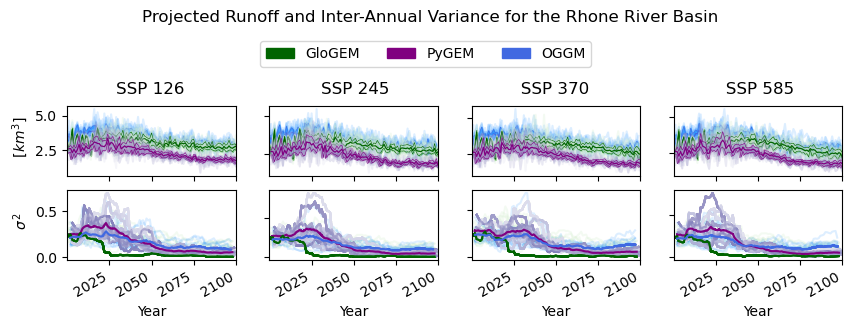

In [35]:
fig, axs = plt.subplots(2, len(SSPs), figsize=(10, 2), sharex=True)

scenarios = ['ssp126','ssp245','ssp370','ssp585']

basin = 'RHONE'
basintext = 'Rhone'

for s, SSP in enumerate(scenarios):                #Plotting Runoff
    #OG won't plot with built-in ds.plot()
    #Trim last value as it goes to zero
    for m, model in enumerate(modelnames_OG_trimmed):
        axs[0,s].plot(yrs_glo_dt[20:-1], trimmed_basin_sums_OG[SSP][basin][:,0:-1].sel(gcm = modelnames_OG_trimmed[m]), color = 'dodgerblue', alpha = 0.15)
    axs[0,s].plot(yrs_glo_dt[20:-1], GCM_mean_OG[SSP][basin][0:-1], color = 'royalblue', linewidth = 0.9, label = 'OGGM')
    axs[0,s].plot(yrs_glo_dt[20:-1], GCM_q1_OG[SSP][basin][0:-1], color = 'royalblue', linewidth = 0.4)
    axs[0,s].plot(yrs_glo_dt[20:-1], GCM_q3_OG[SSP][basin][0:-1], color = 'royalblue', linewidth = 0.4)
    axs[0,s].fill_between(yrs_glo_dt[20:-1], GCM_q1_OG[SSP][basin][0:-1], GCM_q3_OG[SSP][basin][0:-1], color = 'dodgerblue', alpha = 0.5)

    for m in modelnames_glo:
        axs[0,s].plot(yrs_glo_dt, basin_sums_glo[SSP][basin][m], color=axs[0,s].set_prop_cycle(glo_cycler), alpha = 0.25)
    axs[0,s].plot(yrs_glo_dt, GCM_mean_glo[SSP][basin], color = 'darkgreen', linewidth = 0.9, label = 'GloGEM')
    axs[0,s].plot(yrs_glo_dt, GCM_q1_glo[SSP][basin], color = 'darkgreen', linewidth = 0.4)
    axs[0,s].plot(yrs_glo_dt, GCM_q3_glo[SSP][basin], color = 'darkgreen', linewidth = 0.4)
    axs[0,s].fill_between(yrs_glo_dt, GCM_q1_glo[SSP][basin], GCM_q3_glo[SSP][basin], color = 'green')
    axs[0,s].set(xlim=(pd.to_datetime('2000-01-01'), pd.to_datetime('2100-01-01')))

    basin_sums_py[SSP][basin].plot(hue='model', ax=axs[0,s], color=axs[0,s].set_prop_cycle(py_cycler), alpha = 0.25, add_legend=False)   
    GCM_mean_py[SSP][basin].plot(hue='model', ax=axs[0,s], color = 'purple', linewidth = 0.9, add_legend=False, label = 'PyGEM')
    GCM_q1_py[SSP][basin].plot(hue='model', ax=axs[0,s], color = 'purple', linewidth = 0.4, add_legend=False)
    GCM_q3_py[SSP][basin].plot(hue='model', ax=axs[0,s], color = 'purple', linewidth = 0.4, add_legend=False)
    axs[0,s].fill_between(yrs_glo_dt[20::], GCM_q1_py[SSP][basin], GCM_q3_py[which_ssp][basin], color = 'Purple')
    axs[0,s].set(title = '')

    for m in modelnames_glo:               #Plotting Rf inter-annual Variance
        axs[1, s].plot(yrs_dt, annual_variance_glo[SSP][basin][m][20::], color=axs[1, s].set_prop_cycle(glo_cycler), alpha = 0.25)
        
    for m, model in enumerate(modelnames_OG_trimmed):
        axs[1,s].plot(yrs_dt[0:-1], annual_variance_OG[SSP][basin].sel(gcm = modelnames_OG_trimmed[m]), color = 'dodgerblue', alpha = 0.15)        

        annual_variance_py[SSP][basin].plot(hue='model', ax=axs[1, s], color=axs[1, s].set_prop_cycle(py_cycler), alpha = 0.55, add_legend=False)
        
        axs[1,s].plot(yrs_dt, annual_variance_py[SSP][basin].mean(dim = 'model'), color = 'purple', label = 'PyGEM')
        axs[1,s].plot(yrs_dt, mean_variance_glo[SSP][basin][20::], color = 'darkgreen', label = 'GloGEM')
        axs[1,s].plot(yrs_dt[0:-1], annual_variance_OG[SSP][basin].mean(dim = 'gcm'), color = 'royalblue', label = 'OGGM')


for b in range(2):
    for s in range(4):  # Use a different variable name for the inner loop
        axs[1,s].set_xlabel('Year')
        axs[0,s].set_xlabel('')
        axs[1,s].set_xticks([pd.to_datetime('2025'),pd.to_datetime('2050'), pd.to_datetime('2075'), pd.to_datetime('2100')], [2025, 2050, 2075, 2100])
        if s == 0:                                                                    #Setting basin labels
            axs[0,s].set_ylabel(r'  $[km^3]$')
            axs[1,s].set_ylabel(r'  $[km^3] ^2$')
            axs[1,s].set_ylabel(r'  $\sigma^2$')
        if s != 0:
            axs[b,s].set_ylabel('')
            axs[b,s].set_yticklabels('')
        
green_patch = mpatches.Patch(color='darkgreen', label='GloGEM')
purple_patch = mpatches.Patch(color='purple', label='PyGEM') 
blue_patch = mpatches.Patch(color='royalblue', label='OGGM')
axs[0,0].legend(handles=[green_patch, purple_patch, blue_patch],bbox_to_anchor=(3.15, 2.02), ncol=3)
plt.suptitle('Projected Runoff and Inter-Annual Variance for the '+str(basintext)+' River Basin', x=0.488, y=1.36)
plt.title('SSP 126                          SSP 245                         SSP 370                          SSP 585', x=-1.3, y=2.25) 

### Single Basin Runoff Only Plot

Text(-1.3, 1, 'SSP 126                          SSP 245                         SSP 370                          SSP 585')

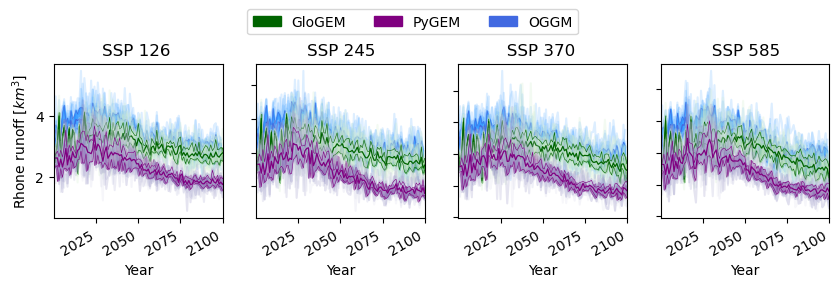

In [41]:
fig, axs = plt.subplots(1, len(SSPs), figsize=(10, 2), sharex=True)

scenarios = ['ssp126','ssp245','ssp370','ssp585']

basin = 'RHONE'
basintext = 'Rhone'

for s, SSP in enumerate(scenarios):                #Plotting Runoff
    #OG won't plot with built-in ds.plot()
    #Trim last value as it goes to zero
    for m, model in enumerate(modelnames_OG_trimmed):
        axs[s].plot(yrs_glo_dt[20:-1], trimmed_basin_sums_OG[SSP][basin][:,0:-1].sel(gcm = modelnames_OG_trimmed[m]), color = 'dodgerblue', alpha = 0.15)
    axs[s].plot(yrs_glo_dt[20:-1], GCM_mean_OG[SSP][basin][0:-1], color = 'royalblue', linewidth = 0.9, label = 'OGGM')
    axs[s].plot(yrs_glo_dt[20:-1], GCM_q1_OG[SSP][basin][0:-1], color = 'royalblue', linewidth = 0.4)
    axs[s].plot(yrs_glo_dt[20:-1], GCM_q3_OG[SSP][basin][0:-1], color = 'royalblue', linewidth = 0.4)
    axs[s].fill_between(yrs_glo_dt[20:-1], GCM_q1_OG[SSP][basin][0:-1], GCM_q3_OG[SSP][basin][0:-1], color = 'dodgerblue', alpha = 0.5)

    for m in modelnames_glo:
        axs[s].plot(yrs_glo_dt, basin_sums_glo[SSP][basin][m], color=axs[s].set_prop_cycle(glo_cycler), alpha = 0.25)
    axs[s].plot(yrs_glo_dt, GCM_mean_glo[SSP][basin], color = 'darkgreen', linewidth = 0.9, label = 'GloGEM')
    axs[s].plot(yrs_glo_dt, GCM_q1_glo[SSP][basin], color = 'darkgreen', linewidth = 0.4)
    axs[s].plot(yrs_glo_dt, GCM_q3_glo[SSP][basin], color = 'darkgreen', linewidth = 0.4)
    axs[s].fill_between(yrs_glo_dt, GCM_q1_glo[SSP][basin], GCM_q3_glo[SSP][basin], color = 'green')
    axs[s].set(xlim=(pd.to_datetime('2000-01-01'), pd.to_datetime('2100-01-01')))

    basin_sums_py[SSP][basin].plot(hue='model', ax=axs[s], color=axs[s].set_prop_cycle(py_cycler), alpha = 0.25, add_legend=False)   
    GCM_mean_py[SSP][basin].plot(hue='model', ax=axs[s], color = 'purple', linewidth = 0.9, add_legend=False, label = 'PyGEM')
    GCM_q1_py[SSP][basin].plot(hue='model', ax=axs[s], color = 'purple', linewidth = 0.4, add_legend=False)
    GCM_q3_py[SSP][basin].plot(hue='model', ax=axs[s], color = 'purple', linewidth = 0.4, add_legend=False)
    axs[s].fill_between(yrs_glo_dt[20::], GCM_q1_py[SSP][basin], GCM_q3_py[which_ssp][basin], color = 'Purple')
    axs[s].set(title = '')

    for s in range(4):  # Use a different variable name for the inner loop
        axs[s].set_xlabel('Year')
        axs[s].set_xticks([pd.to_datetime('2025'),pd.to_datetime('2050'), pd.to_datetime('2075'), pd.to_datetime('2100')], [2025, 2050, 2075, 2100])
        if s == 0:                                                                    #Setting basin labels
            axs[s].set_ylabel(basintext + r' runoff $[km^3]$')
        if s != 0:
            axs[s].set_ylabel('')
            axs[s].set_yticklabels('')
        
green_patch = mpatches.Patch(color='darkgreen', label='GloGEM')
purple_patch = mpatches.Patch(color='purple', label='PyGEM') 
blue_patch = mpatches.Patch(color='royalblue', label='OGGM')
axs[0].legend(handles=[green_patch, purple_patch, blue_patch],bbox_to_anchor=(3.15, 1.4), ncol=3)
#plt.suptitle('Projected Runoff for the '+str(basintext)+' River Basin', x=0.488, y=1.28)
plt.title('SSP 126                          SSP 245                         SSP 370                          SSP 585', x=-1.3, y=1) 

### Examining/Exporting Initial Glaciated Area
Here we are extracting the initial (year 2000) glaciated area used for each basin and glacier model so for Sloan Coates. Will be used to subtracted glaciated area from total basin area to swap runoff values that don't include glacial runoff projections for these, that do. 

#### GloGEM
For the period 1980-2000, the forcing is all ERA5 + noise (per Matthias Huss's email) -- thus we can select only the first of the SSP/GCM combinations and find the year-2000 value there

In [74]:
#Reloading as indexing/period was adjusted for runoff
all_areas = [[] for _ in SSPpaths]

for s, SSPpath in enumerate(SSPpaths):
    model_areas = []
    for modelname in modelnames:
        temp_df = pd.read_csv(fpath0 + modelname  + '/' + SSPpaths[s]  + '/' + 'centraleurope_Area_r1.dat', sep='\s+', index_col="ID")
        model_areas.append(temp_df)
    all_areas[s] = model_areas

In [75]:
baseline_area = all_areas[0][0]

In [76]:
def sum_basin_area(basin_RGI_list, area_data):
    # Create new list to match our RGI formatting
    new_basin_list = [int(str(x)[-4:]) for x in basin_RGI_list]
    
    # Filter new_basin_list to keep only the indexes present in the DataFrame
    new_basin_list = [x for x in new_basin_list if x in area_data.index]
    
    # Extract glaciers contained in the list from original df and create a new df
    new_df = area_data.loc[new_basin_list].copy()
    # print(new_df)
    
    # Sum the values of the glaciers within the basin
    summed_basin_area = new_df.sum()
    #print(summed_basin_runoff)
    
    return summed_basin_area

In [96]:
basins = ['RHINE', 'RHONE', 'PO', 'DANUBE']

basin_area_sums_glo = {}
for b, basin in enumerate(basins):
    basin_area_sums_glo[basin] = sum_basin_area(select_glaciers_json(alpine_basins[basin]), baseline_area)

In [191]:
#Creating our df
initial_basin_areas_glo = {}
for b, basin in enumerate(basins):
    initial_basin_areas_glo[basin] = basin_area_sums_glo[basin][20]

area_df_glo = pd.DataFrame({'GloGEM': initial_basin_areas_glo})
area_df_glo.index.name = 'Basin'

In [192]:
area_df_glo

,GloGEM
Basin,
DANUBE,429.959
PO,335.249
RHINE,364.017
RHONE,956.327


#### PyGEM

In [193]:
#Importing all runoff data, taking annual sum, and converting m^3 to km^3
import glob   #use glob to group files by filename similarities (in this case, SSP)

fpath1 = '/area_annual-ssp585/R11_area_annual_c2_ba1_1set_2000_2100--'
file_pattern = f'{fpathPy + fpath1}*.nc'
file_list = glob.glob(file_pattern)

datasets = []  # Create an empty list for each SSP
if file_list:
    for file in file_list: 
        with xr.open_dataset(file) as ds:
            ds = ds.glac_area_annual.load()
            datasets.append(ds)

    combined_ds = xr.concat(datasets, dim='glacier')  # Concatenate the datasets
    area_ds = combined_ds * 1e-6  #m^2 to km^2

In [194]:
# Sorting into basins
### edit here - modify from CentralEurope-3ModelAgg
basin_areas = {}
for basin, glacier_list in basin_gls.items():
    ## loop over them all, drop the irrelevant IDs, and concatenate the result
    basin_areas[basin] = {}
    ds_list = []
    try:
        ds_filtered = area_ds.where(area_ds.RGIId.isin(glacier_list), drop=True)
        #print(ds_filtered)
        ds_list.append(ds_filtered)
    except ValueError: ## happens if there are no glaciers from this batch in the selected region
        continue
    basin_areas[basin] = xr.concat(ds_list, dim='glacier')

In [195]:
#Summing basins
basin_area_sums_py = {}
for basin, glacier_list in basin_gls.items():
    basin_area_sums_py[basin] = basin_areas[basin].sum(dim='glacier')

In [196]:
#Creating our df
#All models begin with same area so we just select the first one (BCC-CSM2-MR)
initial_basin_areas_py = {}
for b, basin in enumerate(basins):
    initial_basin_areas_py[basin] = basin_area_sums_py[basin].sel(year = 2000, model = 1).values

area_df_py = pd.DataFrame({'PyGEM': initial_basin_areas_py})
area_df_py.index.name = 'Basin'

In [197]:
area_df_py

,PyGEM
Basin,
DANUBE,411.2607711675174
PO,313.4116760799537
RHINE,336.9166635676164
RHONE,917.2935435347366


#### OGGM

In [199]:
#All of the climate models used
modelnames_OG = ['BCC-CSM2-MR', 'CAMS-CSM1-0', 'CESM2', 'CESM2-WACCM', 'CMCC-CM2-SR5','EC-Earth3', 
                'EC-Earth3-Veg', 'FGOALS-f3-L', 'GFDL-ESM4', 'INM-CM4-8','INM-CM5-0', 
                 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorESM2-MM', 'TaiESM1']

alpine_basins = {'RHINE': '6242','RHONE': '6243','PO': '6241','DANUBE':'6202'}

basins = ['RHINE', 'RHONE', 'PO', 'DANUBE']

SSPs = ['ssp126','ssp245','ssp370','ssp585']

# CMCC-CM2-SR5 & TaiESM1 only hold values for ssp585––this is model list without those GCMS
modelnames_OG_trimmed = ['BCC-CSM2-MR', 'CAMS-CSM1-0', 'CESM2', 'CESM2-WACCM', 'EC-Earth3', 
                         'EC-Earth3-Veg', 'FGOALS-f3-L', 'GFDL-ESM4', 'INM-CM4-8',
                           'INM-CM5-0', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorESM2-MM']

#Generic filepath to navigate to Drive folder 
fpathOG1 = '/Users/finnwimberly/Library/CloudStorage/GoogleDrive-fwimberly@middlebury.edu/My Drive/'
fpathOG2 = 'Lizz Research Stuff/Runoff-intercomparison/OGGM/lschuster/runs_2023.3/output/basins/'

In [200]:
#Importing all area data, OGGM is grouped by basin
area_ds = {}
for basin, ID in alpine_basins.items():
    fpath_basin = 'gcm_from_2000_bc_2000_2019/{}/'.format(ID)
    #print(f'{fpathOG + fpath_basin} (1)/*.nc')
    with xr.open_mfdataset(f'{fpathOG1 + fpathOG2 + fpath_basin}/*.nc') as ds:
        ds = ds.area.load()
    area_ds[basin] = ds

In [201]:
#Summing individual glacier runoff into basin totals and converting m^2 to km^2
basin_area_sums_OG = {}
for basin, ID in alpine_basins.items():
    basin_area_sums_OG[basin] = area_ds[basin].sum(dim = 'rgi_id') * 1e-6

In [202]:
#Creating our df
#All models begin with same area so we just select the first GCM (BCC-CSM2-MR) AND ssp126
initial_basin_areas_OG = {}
for b, basin in enumerate(basins):
    initial_basin_areas_OG[basin] = basin_area_sums_OG[basin].sel(time = 2000, gcm = 'BCC-CSM2-MR', scenario = 'ssp126').values

area_df_OG = pd.DataFrame({'OGGM': initial_basin_areas_OG})
area_df_OG.index.name = 'Basin'

In [203]:
area_df_OG

,OGGM
Basin,
DANUBE,419.53708
PO,323.8289
RHINE,351.84827
RHONE,931.4445


In [204]:
#Combining into a single dataframe 
initial_areas_df = pd.concat([area_df_glo, area_df_py, area_df_OG], axis=1)

In [205]:
initial_areas_df

,GloGEM,PyGEM,OGGM
Basin,,,
DANUBE,429.959,411.2607711675174,419.53708
PO,335.249,313.4116760799537,323.8289
RHINE,364.017,336.9166635676164,351.84827
RHONE,956.327,917.2935435347366,931.4445


In [206]:
#Exporting as a CSV
output_dir = '/Users/finnwimberly/Desktop/Lizz Research/CSV Outputs/Area/RGI 11/'

fname = 'RGI-11_InitialAreas.csv'

# Define the full path of the output file
output_path = os.path.join(output_dir, fname)

# Save the DataFrame as CSV
initial_areas_df.to_csv(output_path, header=True, index=True)